# Two-Stage NSBH Impact: f_j^{BNS} Comparison (Lognormal Geometry)

Compare Stage 2 posteriors for BNS and NSBH angles across three f_j^{BNS} values:
- f_j^{BNS} = 0.1
- f_j^{BNS} = 0.5
- f_j^{BNS} = 1.0

Using lognormal geometric-efficiency model.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../..')

plt.style.use('../../configurations/style.mplstyle')
datafiles = Path('../../datafiles')

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import create_geometric_efficiency_lognormal_interpolator
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
import src.init

print('Imports complete.')

Imports complete.


In [2]:
# Shared population setup (run once)
demo_params = {
    'alpha': -0.6,
    'beta_s': -2.5,
    'n': 2.0,
    'theta_c': 3.4,
    'theta_v_max': 10.0,
    'z_model': 'fiducial_delayed_A0.5',
}

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles=datafiles,
    params=demo_params,
    size_test=2_000,
    nsbh_population='fiducial_delayed_cut',
    nsbh_alpha='A0.5',
)

k_interpolator = create_k_interpolator()
bns_distances = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

SIGMA_THETA_C = 0.5
geom_eff_interp = create_geometric_efficiency_lognormal_interpolator(
    sigma_theta_c=SIGMA_THETA_C,
    n_points=200,
    minimum_theta_c=1.0,
    maximum_theta_c=25.0,
)

print(f'FJ_NSBH fixed  = {FJ_NSBH_FIXED}')
print(f'BNS population size  = {len(bns_params.z_arr)}')
print(f'NSBH population size = {len(nsbh_data.z_arr)}')
print(f'Observed yearly GRB rate = {bns_params.yearly_rate:.2f}')

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
FJ_NSBH fixed  = 1
BNS population size  = 60187
NSBH population size = 18332
Observed yearly GRB rate = 18.58


## Stage 1: BNS-only for each f_j^{BNS}

Note: f_j^{BNS} affects the intrinsic rate scaling, so we run Stage 1 for each value.

In [3]:
# Dictionary to store results for each fj_bns value
results_by_fj = {}

FJ_BNS_VALUES = [0.1, 0.5, 1.0]
N_PARAMS_1 = 5
N_WALKERS_1 = 24
N_STEPS_1 = 5000  # shorter for comparison
N_PARAMS_2 = 2
N_WALKERS_2 = 24
N_STEPS_2 = 5000
burn_frac = 0.33
thin = 10

for fj_bns in FJ_BNS_VALUES:
    print(f'\n{"="*60}')
    print(f'Running for FJ_BNS = {fj_bns}')
    print(f'{"="*60}')
    
    # Stage 1
    run_name_stage1 = f'fj_comp_stage1_bns_only_lognormal_fj{fj_bns:.1f}'
    out_dir_stage1 = src.init.create_run_dir(run_name_stage1, output_files_default='Output_files')
    backend_path_stage1 = out_dir_stage1 / 'emcee.h5'
    
    def log_likelihood_stage1_bns_only(thetas, n_events=N_MC_EVENTS, fj=fj_bns):
        A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas
        grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]
        
        geom_eff_bns = geom_eff_interp(theta_c_bns)
        epsilon_bns = geom_eff_bns * fj
        intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
        
        bns_results = simplified_montecarlo(
            grb_thetas, n_events, bns_params, bns_distances, k_interpolator
        )
        bns_trig, bns_analysis = apply_detection_cuts(
            bns_results['p_flux'], bns_results['E_p_obs']
        )
        
        pflux_det = bns_results['p_flux'][bns_analysis]
        epeak_det = bns_results['E_p_obs'][bns_analysis]
        if len(pflux_det) <= 3:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf
        
        logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
        logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)
        
        phys_eff_bns = np.sum(bns_trig) / n_events
        predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
        
        observed_total = bns_params.yearly_rate * bns_params.triggered_years
        if predicted_bns <= 0:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf
        
        logL_poisson = poiss_log(k=observed_total, mu=predicted_bns)
        logL_total = logL_pflux + logL_epeak + logL_poisson
        
        return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns
    
    def log_prior_stage1(thetas):
        A_index, L_L0, L_mu_E, sigma_E, theta_c_bns = thetas
        
        if not (1.5 < A_index < 12):
            return -np.inf
        if not (-2 < L_L0 < 7):
            return -np.inf
        if not (0.1 < L_mu_E < 7):
            return -np.inf
        if not (0 < sigma_E < 2.5):
            return -np.inf
        if not (1 < theta_c_bns < 50):
            return -np.inf
        
        return 0.0
    
    def init_walkers_stage1(n_walkers, seed=123):
        rng = np.random.default_rng(seed)
        return np.column_stack([
            rng.uniform(2.0, 3.5, n_walkers),
            rng.uniform(2.0, 4.5, n_walkers),
            rng.uniform(1.5, 4.5, n_walkers),
            rng.uniform(0.2, 1.2, n_walkers),
            rng.uniform(3.0, 20.0, n_walkers),
        ])
    
    def log_probability_stage1(thetas):
        lp = log_prior_stage1(thetas)
        if not np.isfinite(lp):
            return -np.inf, 0.0, 0.0, 0.0, 0.0
        
        ll = log_likelihood_stage1_bns_only(thetas=thetas, n_events=N_MC_EVENTS, fj=fj_bns)
        if not np.isfinite(ll[0]):
            return -np.inf, 0.0, 0.0, 0.0, 0.0
        
        return lp + ll[0], ll[1], ll[2], ll[3], ll[4]
    
    initial_pos_1, n_steps_rem_1, backend_1 = check_and_resume_mcmc(
        filename=backend_path_stage1,
        n_steps=N_STEPS_1,
        initialize_walkers_func=init_walkers_stage1,
        n_walkers=N_WALKERS_1,
    )
    
    sampler_1 = run_mcmc(
        log_probability_func=log_probability_stage1,
        initial_walkers=initial_pos_1,
        n_iterations=n_steps_rem_1,
        n_walkers=N_WALKERS_1,
        n_params=N_PARAMS_1,
        backend=backend_1,
        blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float)],
    )
    
    print(f'Stage 1 done: {backend_1.iteration} total steps')
    
    # Extract Stage 1 posteriors
    flat_1 = backend_1.get_chain(discard=int(backend_1.iteration * burn_frac), thin=thin, flat=True)
    medians_1 = np.median(flat_1, axis=0)
    spectral_fixed = medians_1[:4].copy()
    theta_bns_stage1_med = medians_1[4]
    
    print(f'Stage 1 theta_c^BNS median = {theta_bns_stage1_med:.3f} deg')
    
    # Stage 2
    run_name_stage2 = f'fj_comp_stage2_bns_plus_nsbh_lognormal_fj{fj_bns:.1f}'
    out_dir_stage2 = src.init.create_run_dir(run_name_stage2, output_files_default='Output_files')
    backend_path_stage2 = out_dir_stage2 / 'emcee.h5'
    
    def log_likelihood_stage2_fixed_spectral(thetas, spectral_fixed, n_events=N_MC_EVENTS, fj=fj_bns):
        theta_c_bns, theta_c_nsbh = thetas
        A_index, L_L0, L_mu_E, sigma_E = spectral_fixed
        grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]
        
        geom_eff_bns = geom_eff_interp(theta_c_bns)
        geom_eff_nsbh = geom_eff_interp(theta_c_nsbh)
        
        epsilon_bns = geom_eff_bns * fj
        epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED
        
        intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
        intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF
        
        bns_results = simplified_montecarlo(
            grb_thetas, n_events, bns_params, bns_distances, k_interpolator
        )
        bns_trig, bns_analysis = apply_detection_cuts(
            bns_results['p_flux'], bns_results['E_p_obs']
        )
        
        nsbh_results = simplified_montecarlo(
            grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
        )
        nsbh_trig, nsbh_analysis = apply_detection_cuts(
            nsbh_results['p_flux'], nsbh_results['E_p_obs']
        )
        
        pflux_det = np.concatenate([
            bns_results['p_flux'][bns_analysis],
            nsbh_results['p_flux'][nsbh_analysis],
        ])
        epeak_det = np.concatenate([
            bns_results['E_p_obs'][bns_analysis],
            nsbh_results['E_p_obs'][nsbh_analysis],
        ])
        
        if len(pflux_det) <= 3:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf
        
        logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
        logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)
        
        phys_eff_bns = np.sum(bns_trig) / n_events
        phys_eff_nsbh = np.sum(nsbh_trig) / n_events
        
        predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
        predicted_nsbh = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh
        predicted_total = predicted_bns + predicted_nsbh
        
        observed_total = bns_params.yearly_rate * bns_params.triggered_years
        if predicted_total <= 0:
            return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf
        
        logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
        logL_total = logL_pflux + logL_epeak + logL_poisson
        
        return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns, predicted_nsbh
    
    def log_prior_stage2(thetas):
        theta_c_bns, theta_c_nsbh = thetas
        
        if not (1 < theta_c_bns < 50):
            return -np.inf
        if not (1 < theta_c_nsbh < 50):
            return -np.inf
        
        return 0.0
    
    def init_walkers_stage2(n_walkers, seed=321):
        rng = np.random.default_rng(seed)
        return np.column_stack([
            rng.uniform(max(1.2, theta_bns_stage1_med * 0.6), min(45.0, theta_bns_stage1_med * 1.4), n_walkers),
            rng.uniform(2.0, 25.0, n_walkers),
        ])
    
    def log_probability_stage2(thetas):
        lp = log_prior_stage2(thetas)
        if not np.isfinite(lp):
            return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0
        
        ll = log_likelihood_stage2_fixed_spectral(
            thetas=thetas,
            spectral_fixed=spectral_fixed,
            n_events=N_MC_EVENTS,
            fj=fj_bns,
        )
        if not np.isfinite(ll[0]):
            return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0
        
        return lp + ll[0], ll[1], ll[2], ll[3], ll[4], ll[5]
    
    initial_pos_2, n_steps_rem_2, backend_2 = check_and_resume_mcmc(
        filename=backend_path_stage2,
        n_steps=N_STEPS_2,
        initialize_walkers_func=init_walkers_stage2,
        n_walkers=N_WALKERS_2,
    )
    
    sampler_2 = run_mcmc(
        log_probability_func=log_probability_stage2,
        initial_walkers=initial_pos_2,
        n_iterations=n_steps_rem_2,
        n_walkers=N_WALKERS_2,
        n_params=N_PARAMS_2,
        backend=backend_2,
        blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float), ('mu_nsbh', float)],
    )
    
    print(f'Stage 2 done: {backend_2.iteration} total steps')
    
    # Extract Stage 2 posteriors
    flat_2 = backend_2.get_chain(discard=int(backend_2.iteration * burn_frac), thin=thin, flat=True)
    theta_bns_2 = flat_2[:, 0]
    theta_nsbh_2 = flat_2[:, 1]
    
    results_by_fj[fj_bns] = {
        'theta_bns': theta_bns_2,
        'theta_nsbh': theta_nsbh_2,
        'backend_2': backend_2,
    }
    
    print(f'Median theta_c^BNS = {np.median(theta_bns_2):.3f} deg')
    print(f'Median theta_c^NSBH = {np.median(theta_nsbh_2):.3f} deg')

print(f'\n{"="*60}')
print('All runs complete!')
print(f'{"="*60}')


Running for FJ_BNS = 0.1
Creating new directory : Output_files/fj_comp_stage1_bns_only_lognormal_fj0.1
Starting new run


100%|██████████| 5000/5000 [05:52<00:00, 14.18it/s]


Stage 1 done: 5000 total steps
Stage 1 theta_c^BNS median = 28.978 deg
Creating new directory : Output_files/fj_comp_stage2_bns_plus_nsbh_lognormal_fj0.1
Starting new run


100%|██████████| 5000/5000 [08:31<00:00,  9.77it/s]


Stage 2 done: 5000 total steps
Median theta_c^BNS = 8.420 deg
Median theta_c^NSBH = 3.414 deg

Running for FJ_BNS = 0.5
Creating new directory : Output_files/fj_comp_stage1_bns_only_lognormal_fj0.5
Starting new run


...

Stage 2 done: 5000 total steps
Median theta_c^BNS = 2.833 deg
Median theta_c^NSBH = 7.223 deg

Running for FJ_BNS = 1.0
Creating new directory : Output_files/fj_comp_stage1_bns_only_lognormal_fj1.0
Starting new run


100%|██████████| 5000/5000 [5:10:35<00:00,  3.73s/it]      


Stage 1 done: 5000 total steps
Stage 1 theta_c^BNS median = 11.373 deg
Creating new directory : Output_files/fj_comp_stage2_bns_plus_nsbh_lognormal_fj1.0
Starting new run


100%|██████████| 5000/5000 [08:32<00:00,  9.75it/s]


Stage 2 done: 5000 total steps
Median theta_c^BNS = 5.001 deg
Median theta_c^NSBH = 25.145 deg

All runs complete!


## Individual Banana Plots for Each f_j^{BNS}

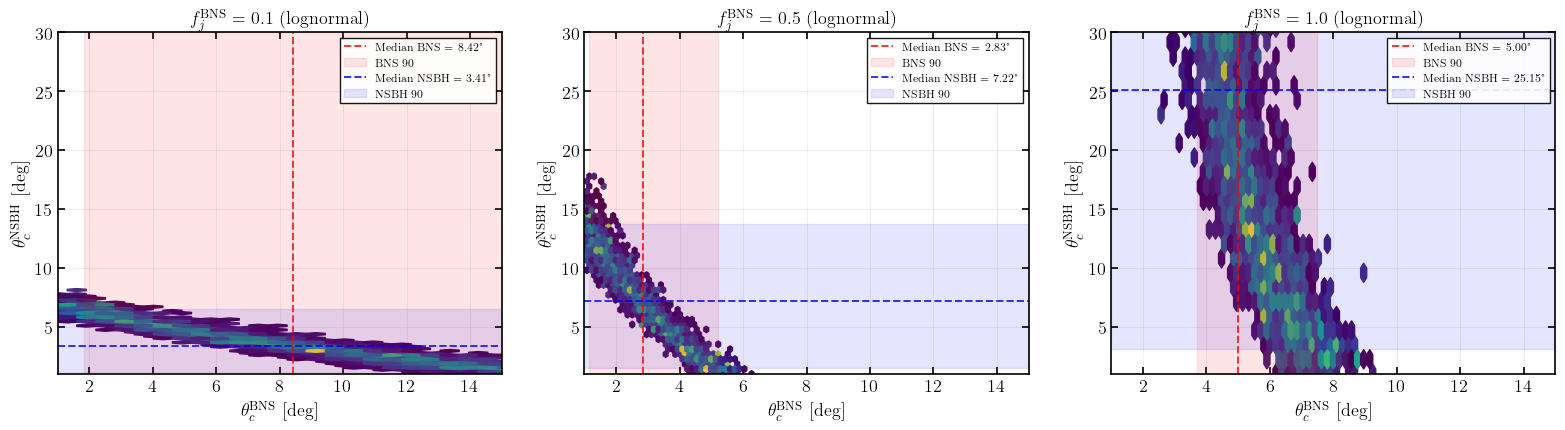

Individual banana plots saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, fj_bns in enumerate(FJ_BNS_VALUES):
    theta_bns = results_by_fj[fj_bns]['theta_bns']
    theta_nsbh = results_by_fj[fj_bns]['theta_nsbh']
    
    median_bns = np.median(theta_bns)
    median_nsbh = np.median(theta_nsbh)
    
    # 90% CI
    ci_bns = np.percentile(theta_bns, [5, 95])
    ci_nsbh = np.percentile(theta_nsbh, [5, 95])
    
    span_min_bns, span_max_bns = ci_bns[0], ci_bns[1]
    span_min_nsbh, span_max_nsbh = ci_nsbh[0], ci_nsbh[1]
    
    ax = axes[idx]
    hb = ax.hexbin(theta_bns, theta_nsbh, gridsize=35, mincnt=1, cmap='viridis')
    
    # Median and CI spans
    ax.axvline(median_bns, ls='--', lw=1.4, color='red', alpha=0.8, label=f'Median BNS = {median_bns:.2f}°')
    ax.axvspan(span_min_bns, span_max_bns, color='red', alpha=0.1, label=f'BNS 90% CI')
    
    ax.axhline(median_nsbh, ls='--', lw=1.4, color='blue', alpha=0.8, label=f'Median NSBH = {median_nsbh:.2f}°')
    ax.axhspan(span_min_nsbh, span_max_nsbh, color='blue', alpha=0.1, label=f'NSBH 90% CI')
    
    ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ [deg]')
    ax.set_ylabel(r'$\theta_c^{\mathrm{NSBH}}$ [deg]')
    ax.set_title(f'$f_j^{{\mathrm{{BNS}}}} = {fj_bns}$ (lognormal)')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(1, 15)
    ax.set_ylim(1, 30)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('banana_plots_fj_comparison_lognormal.pdf', dpi=150, bbox_inches='tight')
plt.show()

print('Individual banana plots saved.')

## Combined Contour Plot with RE Measurements

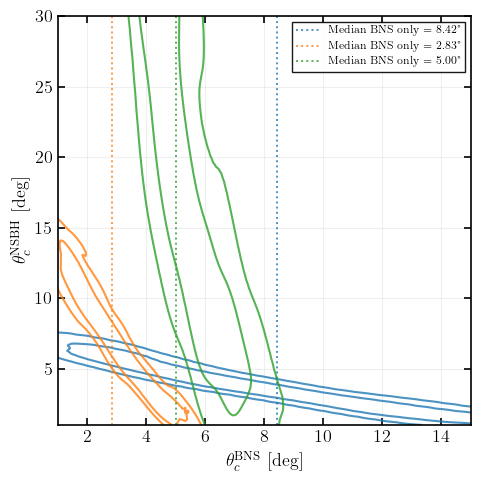

Contour plots saved.


In [ ]:
# Compute contour levels (68%, 95%) for each f_j^BNS
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(5, 5))

colors_fj = {
    0.1: 'tab:blue',
    0.5: 'tab:orange',
    1.0: 'tab:green',
}

for idx, fj_bns in enumerate(FJ_BNS_VALUES):
    theta_bns = results_by_fj[fj_bns]['theta_bns']
    theta_nsbh = results_by_fj[fj_bns]['theta_nsbh']
    
    #median_bns_only = np.median(results_by_fj[fj_bns]['backend_2'].get_chain(discard=int(results_by_fj[fj_bns]['backend_2'].iteration * burn_frac), thin=thin, flat=True)[:, 0])

    median_bns = np.median(theta_bns)
    median_nsbh = np.median(theta_nsbh)
    
    # 2D density estimation
    xy = np.vstack([theta_bns, theta_nsbh])
    kde = gaussian_kde(xy)
    
    # Create grid for contours
    x = np.linspace(1, 15, 150)
    y = np.linspace(1, 30, 150)
    X, Y = np.meshgrid(x, y)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)
    
    # Contour plot
    levels = [np.percentile(kde(xy), 32), np.percentile(kde(xy), 5)]  # 68% and 95%
    contours = ax.contour(
        X, Y, Z, levels=sorted(levels), 
        colors=colors_fj[fj_bns], 
        linewidths=1.5, alpha=0.8
    )
    #ax.axvline(median_bns_only, ls=':', lw=1.4, color=colors_fj[fj_bns], alpha=0.8, label=f'Median BNS only = {median_bns_only:.2f}°')
    #ax.clabel(contours, inline=True, fontsize=8)
    
    # Scatter with alpha
    # ax.scatter(theta_bns, theta_nsbh, alpha=0.3, s=10, color='black')
    
    # RE measurement line (placeholder - adjust based on actual RE data)
    RE_obs = 0.26
    theta_threshold = 10.0
 
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ [deg]')
ax.set_ylabel(r'$\theta_c^{\mathrm{NSBH}}$ [deg]')
ax.grid(True, alpha=0.2)
ax.set_xlim(1, 15)
ax.set_ylim(1, 30)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('contour_plots_fj_comparison_lognormal.pdf', dpi=150, bbox_inches='tight')
plt.show()

print('Contour plots saved.')